# Task 3 — Analisi esplorativa di `training.csv`

> 📄 Documentazione completa e motivazioni: [`docs/task3.md`](../docs/task3.md)

## 0. Setup

Importiamo le librerie per l'analisi e la visualizzazione: `pandas` e `numpy` per la
manipolazione dei dati, `matplotlib` e `seaborn` per i grafici. L'analisi
esplorativa (EDA)* ha due obiettivi: (1) verificare che
`training.csv` non contenga osservazioni palesemente errate e (2) comprenderne la struttura
tramite statistiche e rappresentazioni grafiche (boxplot, matrice di correlazione, pairplot).

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")   # stile

In [65]:
dataFrame = pd.read_csv("../data/processed/training.csv" ,sep=";")
print(f"Il dataset contiene : {dataFrame.shape[0]} istanze e {dataFrame.shape[1]} attributi")
dataFrame.head(10)

Il dataset contiene : 41176 istanze e 20 attributi


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
5,45,services,married,basic.9y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
7,41,blue-collar,married,university.degree,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
9,25,services,single,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


In [66]:
# Separiamo attributi numerici e nominali
numerici = dataFrame.select_dtypes(include=np.number).drop(columns="y").columns.tolist()
nominali  = dataFrame.select_dtypes(exclude=np.number).columns.tolist()
print("Numerici:", numerici)
print("Nominali:", nominali)

Numerici: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Nominali: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


## 1. Verifica di osservazioni palesemente errate


### 1.1 Statistiche descrittive e valori impossibili

Calcoliamo media, deviazione standard, minimo e massimo di ogni attributo numerico. Cerchiamo
in particolare **valori impossibili** (età negative, importi assurdi, ecc.). Dalla tabella si
nota che gli intervalli sono plausibili — ad esempio l'età va da 17 a 98 anni — con due
eccezioni apparenti che richiedono interpretazione: `pdays` con massimo 999 e `duration` con
valori molto alti. Le analizziamo nelle sezioni seguenti.

In [67]:
dataFrame[numerici].describe().T[["mean", "std", "min", "max"]].round(2)

,mean,std,min,max
age,40.02,10.42,17.00,98.00
campaign,2.57,2.77,1.00,56.00
pdays,962.46,186.94,0.00,999.00
previous,0.17,0.49,0.00,7.00
emp.var.rate,0.08,1.57,-3.40,1.40
cons.price.idx,93.58,0.58,92.20,94.77
cons.conf.idx,-40.50,4.63,-50.80,-26.90
euribor3m,3.62,1.73,0.63,5.04
nr.employed,5167.03,72.25,4963.60,5228.10


### 1.2 Outlier estremi

Esaminiamo i valori massimi e minimi di `campaign`. Si tratta di valori **estremi ma
plausibili**: un cliente può essere stato contattato fino a 56 volte nella stessa campagna. 
**Non sono errori da rimuovere**, ma osservazioni reali
nella coda della distribuzione.

In [68]:
print(f"campaign max = {dataFrame['campaign'].max()} contatti nella stessa campagna")


campaign max = 56 contatti nella stessa campagna


### 1.3 Il codice speciale di `pdays`

L'attributo `pdays` (giorni trascorsi dall'ultimo contatto di una campagna precedente) usa il
valore convenzionale **999** per indicare *"cliente mai contattato prima"*. **Non è un errore né
un outlier**: è un codice speciale, documentato nella descrizione del dataset. Come mostra
l'output, riguarda la **stragrande maggioranza** delle istanze (~96%), il che significa che per
quasi tutti i clienti non esiste storia di contatti precedenti. Va tenuto a mente: trattare 999
come un numero "vero" distorcerebbe medie e correlazioni di questo attributo.

Sulla base di questa osservazione, si decide di escludere pdays dalle variabili di addestramento: l’attributo è infatti una **near‑constant feature**, cioè una variabile che assume quasi sempre lo stesso valore. Una caratteristica di questo tipo risulta poco informativa e può addirittura introdurre rumore, compromettendo le prestazioni di molti modelli.

In [69]:
quota_999 = (dataFrame["pdays"] == 999).mean()
print(f"pdays = 999 ('mai contattato prima'): {quota_999:.1%} delle istanze")

pdays = 999 ('mai contattato prima'): 96.3% delle istanze


## 2. Boxplot degli attributi numerici

I **boxplot**  riassumono graficamente la distribuzione di ciascun attributo numerico:
mediana, quartili e outlier. Permettono di cogliere a colpo d'occhio l'**asimmetria** delle
distribuzioni e la presenza di code lunghe. Si osservano molti punti oltre i baffi per `campaign`,
`duration` e `previous`: code destre marcate, tipiche di variabili di conteggio. `pdays` appare
schiacciato sul valore 999 per via del codice speciale visto sopra.

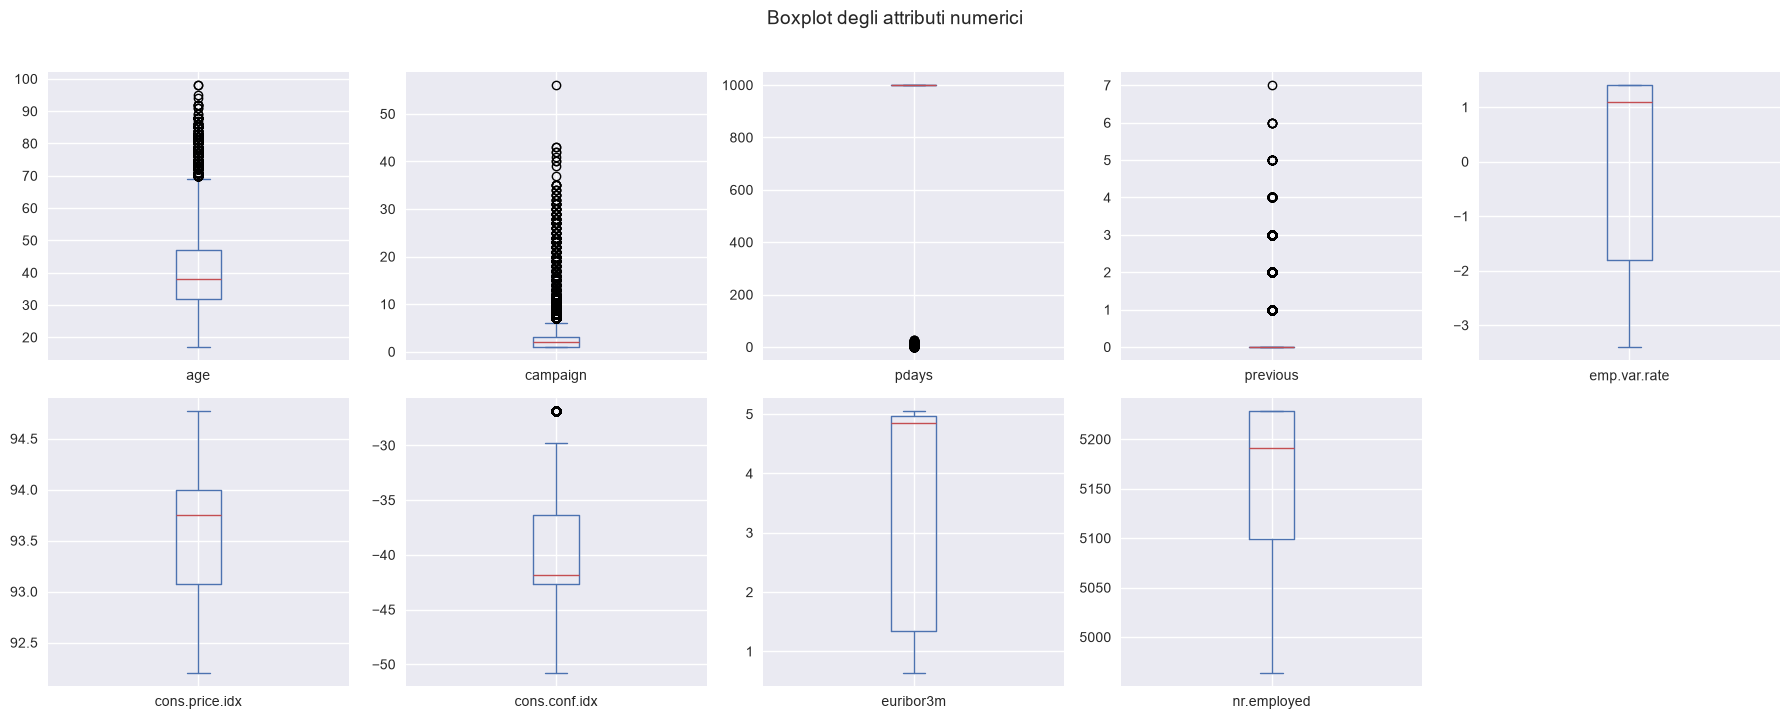

In [71]:
dataFrame[numerici].plot(kind="box", subplots=True, layout=(2, 5),
                   figsize=(18, 7), sharex=False, sharey=False)
plt.suptitle("Boxplot degli attributi numerici", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 3. Matrice di correlazione

La **matrice di correlazione**  mostra le correlazioni lineari di Pearson tra tutti gli
attributi numerici e il target. Serve a due scopi: individuare quali variabili sono associate
all'esito (`y`) e rilevare la **multicollinearità** tra predittori. Emerge chiaramente un blocco
di variabili economiche fortemente correlate tra loro — `emp.var.rate`, `euribor3m`,
`nr.employed` — che misurano sostanzialmente lo stesso contesto macroeconomico. Questa
ridondanza è rilevante: modelli come il Naïve Bayes, che assumono indipendenza tra le feature,
ne sono penalizzati.

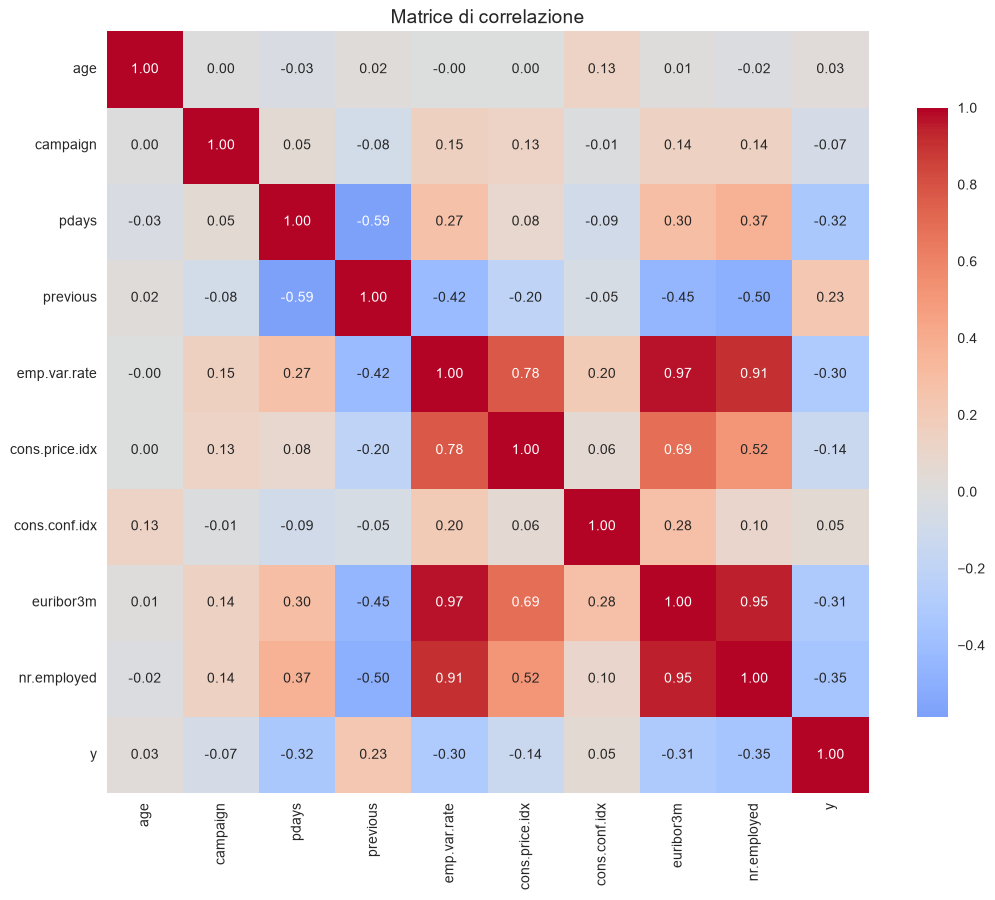

In [72]:
corr = dataFrame[numerici + ["y"]].corr(numeric_only=True)

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Matrice di correlazione", fontsize=14)
plt.tight_layout()
plt.show()

### 3.1 Correlazione con il target

Isoliamo la colonna delle correlazioni con `y`, ordinandole. Il predittore più correlato è di
gran lunga **`duration`** (~0.41) — ma proprio per questo è anche il più pericoloso, per il
problema di leakage già discusso. Seguono `previous` (positivo) e, con segno **negativo**, le
variabili macroeconomiche (`nr.employed`, `pdays`, `euribor3m`, `emp.var.rate`): quando
l'occupazione e i tassi sono alti, la propensione a sottoscrivere cala. Nessun predittore
numerico, a parte `duration`, è fortemente correlato col target: un segnale che la sola
informazione numerica non basterà e che gli attributi nominali avranno un ruolo importante.

In [73]:
corr["y"].drop("y").sort_values(ascending=False).round(3)

previous          0.230
cons.conf.idx     0.055
age               0.030
campaign         -0.066
cons.price.idx   -0.136
emp.var.rate     -0.298
euribor3m        -0.308
pdays            -0.325
nr.employed      -0.355
Name: y, dtype: float64

## 4. Pairplot

Il **pairplot**  mostra le relazioni a coppie tra un sottoinsieme di attributi
numerici, colorando i punti per classe (`yes`/`no`). Per ragioni di leggibilità e di costo
computazionale lo costruiamo su un **campione di 2000 istanze** (con seme fissato) e in versione
*corner* (solo il triangolo inferiore). Il grafico aiuta a vedere se le due classi si separano in
qualche proiezione bidimensionale: si nota che la separazione è generalmente **debole** sulle
sole variabili numeriche selezionate, a conferma della difficoltà del problema.

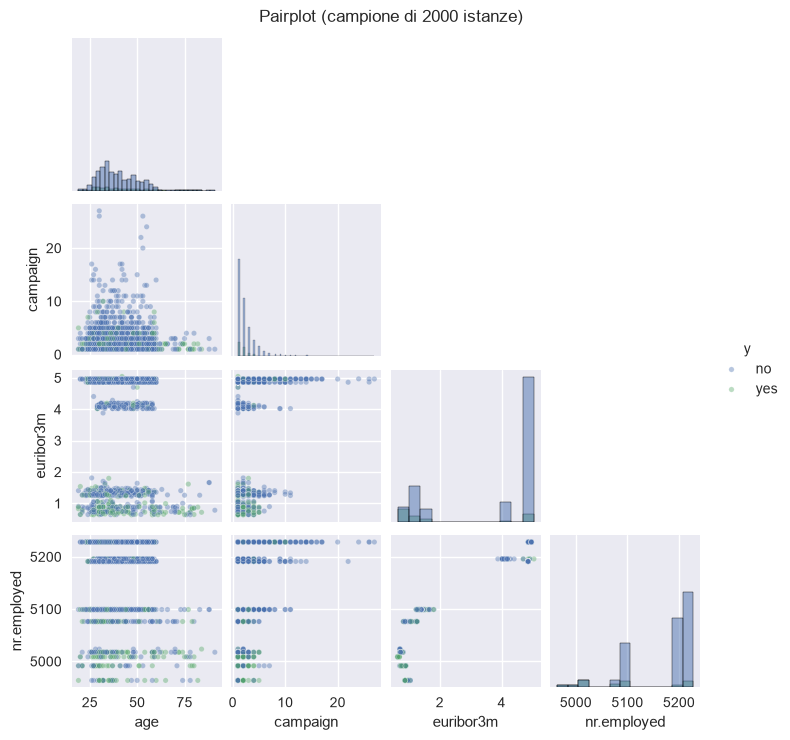

In [74]:
sub = ["age", "campaign", "euribor3m", "nr.employed", "y"]
dfp = dataFrame[sub].copy()
dfp["y"] = dfp["y"].map({0: "no", 1: "yes"})
campione = dfp.sample(2000, random_state=10)

g = sns.pairplot(campione, hue="y", diag_kind="hist",
                 plot_kws={"alpha": 0.4, "s": 15}, height=1.8, corner=True)
g.figure.suptitle("Pairplot (campione di 2000 istanze)", y=1.02)
plt.show()

## 5. Analisi degli attributi nominali

L'EDA numerica va completata con quella sugli attributi **nominali**, che in questo dataset sono
molto informativi. Per ciascun attributo calcoliamo il **tasso di sottoscrizione** (proporzione di
`yes`) per ogni categoria: è il modo più diretto di vedere quali categorie "spingono" verso la
classe positiva. I grafici a barre orizzontali rendono immediato il confronto tra categorie di
`job`, `education`, `poutcome` e `month`.

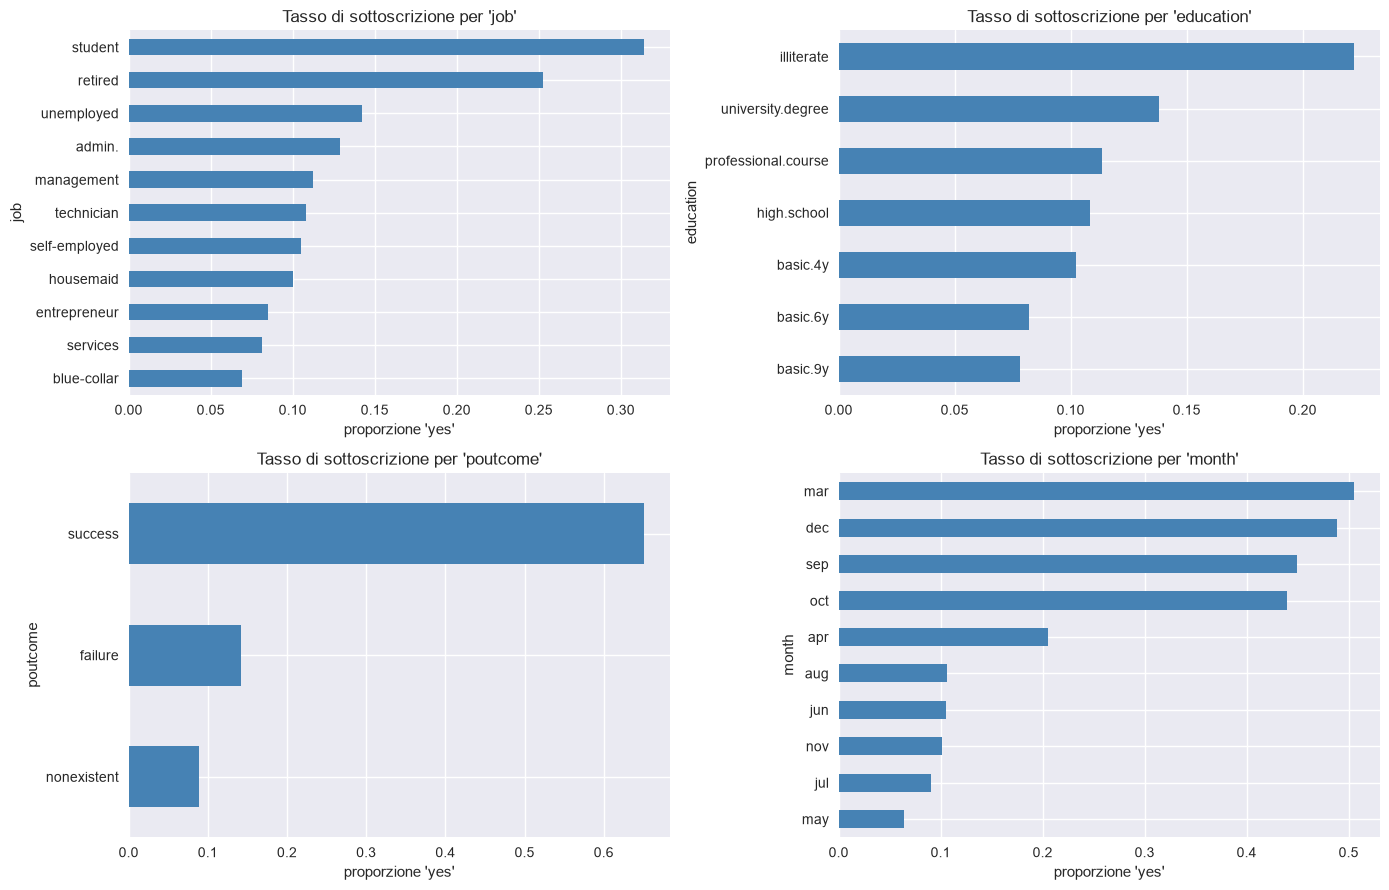

In [75]:
# Tasso di 'yes' per alcune nominali chiave
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

def barplot_tasso(attr, ax):
    (dataFrame.groupby(attr)["y"].mean().sort_values()
       .plot(kind="barh", ax=ax, color="steelblue"))
    ax.set_title(f"Tasso di sottoscrizione per '{attr}'")
    ax.set_xlabel("proporzione 'yes'")

attrs = pd.Series(["job", "education", "poutcome", "month"])
attrs.reset_index().apply(
    lambda r: barplot_tasso(r[0], axes.flat[r["index"]]), axis=1)
plt.tight_layout()
plt.show()

In [76]:
# Esempio numerico: poutcome e' molto informativo, infatti il tasso di 'yes' e' molto alto quando e' un successo
dataFrame.groupby("poutcome")["y"].mean().sort_values(ascending=False).round(3)

poutcome
success        0.651
failure        0.142
nonexistent    0.088
Name: y, dtype: float64

---
## Riepilogo

- **Nessuna osservazione palesemente errata**: nessun valore impossibile, nessun
  duplicato. Da interpretare: il codice `pdays=999` ("mai contattato") e i valori
  `unknown` (mancanti).
- **`duration`** è il più correlato col target ma va **escluso** dal modello (data
  leakage): lo faremo nel Task 5.
- Forte **multicollinearità** tra le variabili economiche.
- Attributi nominali molto informativi: **`poutcome`**, `contact`, `month`.

**Prossimo passo (Task 4):** valutare i classificatori manuali (1R e Naïve Bayes) su
`training.csv` o suoi sottoinsiemi, cercando di ottimizzarne le prestazioni.